# TP2 — Reconstrucción 3D del buda (dataset de cátedra)

**I308 Visión Artificial · UdeSA · Santiago Luis Groba Alonso**

Pipeline estéreo sobre `datasets/stereo_budha_charuco/` (cátedra). El board ChArUco con layout conocido (5×7, `DICT_6X6_250`) permite usar la API estándar de OpenCV para pose. Se procesan los 43 pares estéreo, se fusionan las nubes parciales en un único PLY y se mide la altura del buda.

## 0. Setup

Importamos librerías y cargamos la calibración estéreo precomputada (`stereo_calibration.npz` provista por cátedra). Definimos los parámetros del board ChArUco (5×7 squares, `DICT_6X6_250`, square 52.6 mm, marker 31.3 mm).

In [1]:
import glob, os, sys
from pathlib import Path
import cv2
import matplotlib.pyplot as plt
import numpy as np
import open3d as o3d
from tqdm import tqdm

DATASET_DIR = Path('datasets/stereo_budha_charuco')
CAPTURES_DIR = DATASET_DIR / 'captures'

# ChArUco board de catedra
CHARUCO_SQUARES_X = 5
CHARUCO_SQUARES_Y = 7
CHARUCO_SQUARE_MM = 52.6
CHARUCO_MARKER_MM = 31.3
CHARUCO_DICT = cv2.aruco.getPredefinedDictionary(cv2.aruco.DICT_6X6_250)

# Calibracion estereo precomputada
cal = np.load(DATASET_DIR / 'stereo_calibration.npz')
K_L, D_L = cal['left_K'], cal['left_dist']
K_R, D_R = cal['right_K'], cal['right_dist']
R_stereo, T_stereo = cal['R'], cal['T']
IMAGE_SIZE = tuple(int(v) for v in cal['image_size'])
baseline_mm = float(np.linalg.norm(T_stereo))
print(f'image_size = {IMAGE_SIZE}   baseline = {baseline_mm:.2f} mm')

def numeric_sort(fn):
    return int(os.path.basename(fn).split('_')[-1].split('.')[0])

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.
image_size = (1920, 1080)   baseline = 60.38 mm


## 1. Rectificación estéreo

`cv2.stereoRectify` calcula `R1, R2, P1, P2, Q` a partir de la calibración. Los mapas de `initUndistortRectifyMap` se aplican con `cv2.remap` para hacer des-distorsión + rectificación en una sola pasada. Después de esto, las epipolares son horizontales y `StereoMatcher` puede buscar correspondencias sobre la misma fila.

In [2]:
R1, R2, P1, P2, Q, _, _ = cv2.stereoRectify(
    K_L, D_L, K_R, D_R, IMAGE_SIZE, R_stereo, T_stereo, alpha=0,
)
left_map_x, left_map_y = cv2.initUndistortRectifyMap(K_L, D_L, R1, P1, IMAGE_SIZE, cv2.CV_32FC1)
right_map_x, right_map_y = cv2.initUndistortRectifyMap(K_R, D_R, R2, P2, IMAGE_SIZE, cv2.CV_32FC1)

def rectify(left_bgr, right_bgr):
    return (cv2.remap(left_bgr, left_map_x, left_map_y, cv2.INTER_LINEAR),
            cv2.remap(right_bgr, right_map_x, right_map_y, cv2.INTER_LINEAR))

f_px = float(P1[0, 0])
B_mm = float(-P2[0, 3] / P2[0, 0])
print(f'P1 fx = {f_px:.2f} px    baseline rectificada = {B_mm:.2f} mm')

P1 fx = 614.53 px    baseline rectificada = 60.38 mm


## 2. Disparidad con CREStereo

Usamos **CREStereo** (CVPR 2022) vía el módulo `disparity` de cátedra (`ejemplos clase/disparity/`). Es un método deep-learning basado en redes recurrentes que produce disparidad densa con bordes limpios — mucho mejor que `StereoBM`/`StereoSGBM` en zonas con poca textura, que es el caso del buda (figurín de cerámica con detalles finos).

Requiere `onnxruntime`. El modelo (`crestereo_combined_iter10_720x1280.onnx`, ~30 MB) se descarga automáticamente la primera vez a `models/` y queda cacheado.

In [3]:
sys.path.insert(0, 'ejemplos clase')
from disparity.method_cre_stereo import CREStereo
from disparity.methods import Calibration, InputPair, Config

_cre_calib = Calibration(
    width=IMAGE_SIZE[0], height=IMAGE_SIZE[1],
    baseline_meters=baseline_mm / 1000,
    fx=float(K_L[0, 0]), fy=float(K_L[1, 1]),
    cx0=float(K_L[0, 2]), cx1=float(K_L[0, 2]), cy=float(K_L[1, 2]),
    depth_range=[0.05, 20.0], left_image_rect_normalized=[0, 0, 1, 1],
)
_models_path = Path('models'); _models_path.mkdir(exist_ok=True)
_cre_method = CREStereo(Config(models_path=_models_path))
_cre_method.parameters['Shape'].set_value('1280x720')

def compute_disparity(left_rect_bgr, right_rect_bgr):
    pair = InputPair(left_rect_bgr, right_rect_bgr, _cre_calib)
    return _cre_method.compute_disparity(pair).disparity_pixels

## 3. Pose del mundo (ChArUco)

Para fusionar las nubes parciales necesitamos saber, en cada captura, la pose de la cámara respecto a un frame de mundo común. Anclamos el origen al board ChArUco.

**Approach**: el buda en el centro del board oculta la mayoría de los corners interpolados (`CharucoDetector.detectBoard` solo encuentra 3-4 corners). En vez de eso, detectamos los markers ArUco individuales y los matcheamos contra sus posiciones 3D conocidas en el board (`board.getObjPoints()`). Con 7+ markers visibles tenemos 28+ correspondencias 3D-2D para `cv2.solvePnP`, robusto y sin ambigüedad planar (a diferencia de single-marker IPPE_SQUARE).

**Convención del frame del mundo**: reordenamos `obj_pts` con swap X↔Y (rotación de 90° alrededor de Z respecto al frame nativo OpenCV) para que `+X` y `+Y` queden alineados con los bordes del board en la dirección intuitiva y `+Z` apunte hacia arriba (out of board, hacia la cámara cuando el board está sobre la mesa).

Markers detectados: 7   tvec = [98.7, 21.8, 529.8] mm


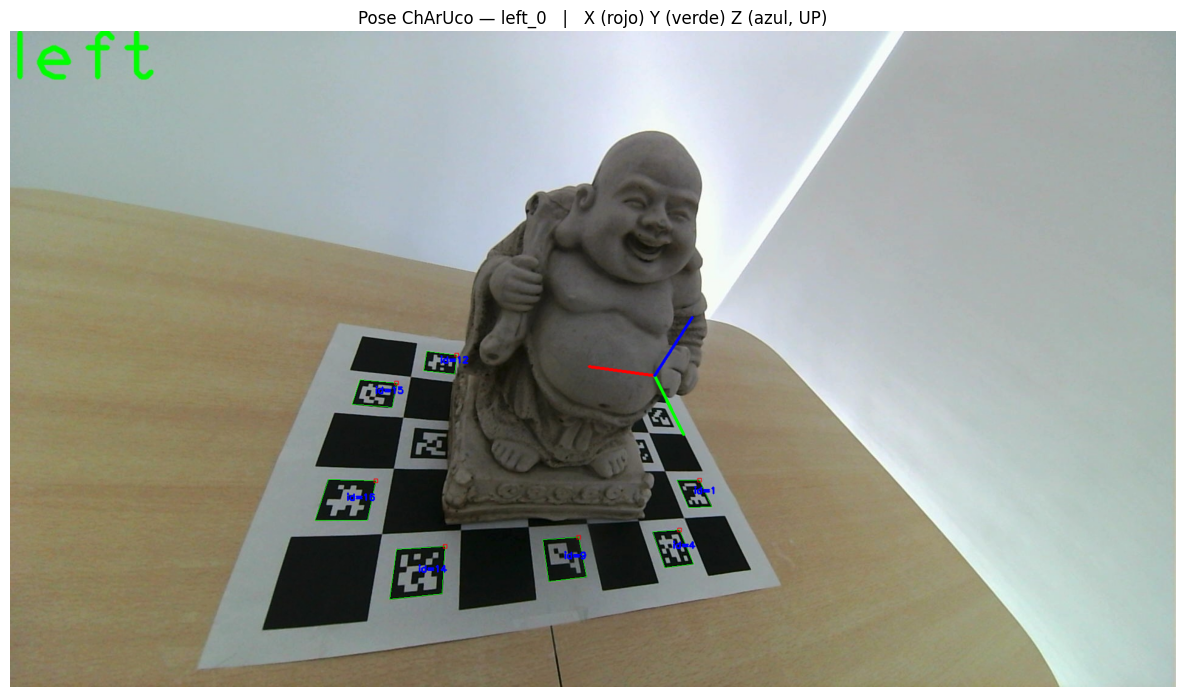

In [4]:
board = cv2.aruco.CharucoBoard(
    (CHARUCO_SQUARES_X, CHARUCO_SQUARES_Y),
    CHARUCO_SQUARE_MM, CHARUCO_MARKER_MM, CHARUCO_DICT,
)
_aruco_detector = cv2.aruco.ArucoDetector(CHARUCO_DICT, cv2.aruco.DetectorParameters())
_board_obj_corners = board.getObjPoints()       # list of (4,3) per marker
_board_ids = np.array(board.getIds()).ravel()


def estimate_world_pose(left_bgr, K, dist, min_markers=2):
    """Pose del board en el frame de camara izq.
    Devuelve (rvec, tvec, m_corners, m_ids) o None."""
    gray = cv2.cvtColor(left_bgr, cv2.COLOR_BGR2GRAY) if left_bgr.ndim == 3 else left_bgr
    m_corners, m_ids, _ = _aruco_detector.detectMarkers(gray)
    if m_ids is None or len(m_ids) < min_markers:
        return None
    obj_pts_list, img_pts_list = [], []
    for det_corner, det_id in zip(m_corners, m_ids.ravel()):
        idx = np.where(_board_ids == int(det_id))[0]
        if len(idx) == 0:
            continue
        # Swap X<->Y (Z queda 0): rotacion 90 alrededor de Z. +X y +Y a lo
        # largo de los bordes del board, +Z out of board (hacia arriba).
        op = _board_obj_corners[idx[0]].copy()
        op[:, [0, 1]] = op[:, [1, 0]]
        obj_pts_list.append(op)
        img_pts_list.append(det_corner[0])
    if len(obj_pts_list) < min_markers:
        return None
    obj_pts = np.vstack(obj_pts_list).astype(np.float32)
    img_pts = np.vstack(img_pts_list).astype(np.float32)
    ok, rvec, tvec = cv2.solvePnP(obj_pts, img_pts, K, dist)
    return (rvec, tvec, m_corners, m_ids) if ok else None


# Sanity check sobre left_0
test_img = cv2.imread(str(CAPTURES_DIR / 'left_0.jpg'))
res = estimate_world_pose(test_img, K_L, D_L)
assert res is not None
rvec, tvec, m_corners, m_ids = res
print(f'Markers detectados: {len(m_ids)}   tvec = [{tvec[0,0]:.1f}, {tvec[1,0]:.1f}, {tvec[2,0]:.1f}] mm')

vis = test_img.copy()
cv2.aruco.drawDetectedMarkers(vis, m_corners, m_ids)
cv2.drawFrameAxes(vis, K_L, D_L, rvec, tvec, length=CHARUCO_SQUARE_MM * 2, thickness=4)
fig, ax = plt.subplots(figsize=(12, 7))
ax.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
ax.set_title('Pose ChArUco — left_0   |   X (rojo) Y (verde) Z (azul, UP)')
ax.axis('off'); plt.tight_layout(); plt.show()

## 4. Reconstrucción 3D de un par

Combinamos la disparidad con la pose para obtener una nube de puntos en el frame del mundo:

1. **Depth**: `Z = f · B / d` para cada pixel con disparidad válida (`f`, `B` rectificados desde `P1`, `P2`).
2. **Back-projection**: `X = (u − cx) · Z / f`, `Y = (v − cy) · Z / f`, `Z = depth` → puntos en frame de cámara izq RECTIFICADA.
3. **Filtro de profundidad**: descartamos `depth ∉ [100, 2000] mm`.
4. **Transformación al mundo**: rectificado → unrectificado (con `R1^T`) → mundo (con inversa de la pose del marker). Se compone en una matriz 4×4 `T_world_rect` y se aplica al batch.
5. **PointCloud**: `o3d.geometry.PointCloud` con los puntos transformados y los colores del pixel correspondiente en la izquierda rectificada.

In [5]:
def compute_depth(disparity, f, B):
    """Z = f * B / d. Disparidad <= 0 -> 0 (mascara aparte)."""
    depth = np.zeros_like(disparity, dtype=np.float32)
    valid = disparity > 0
    depth[valid] = (f * B) / disparity[valid]
    return depth, valid


def pair_to_world_pointcloud(left_bgr, left_rect_bgr, disparity,
                              depth_min=100.0, depth_max=2000.0):
    pose = estimate_world_pose(left_bgr, K_L, D_L)
    if pose is None:
        return None
    rvec, tvec, _, _ = pose
    R_marker, _ = cv2.Rodrigues(rvec)

    cx, cy = float(P1[0, 2]), float(P1[1, 2])
    depth, valid = compute_depth(disparity, f_px, B_mm)
    H, W = depth.shape
    v_grid, u_grid = np.mgrid[0:H, 0:W].astype(np.float32)
    X = (u_grid - cx) * depth / f_px
    Y = (v_grid - cy) * depth / f_px
    pts_rect = np.stack([X, Y, depth], axis=-1)

    mask = valid & (depth >= depth_min) & (depth <= depth_max)
    pts = pts_rect[mask].astype(np.float32)
    colors = cv2.cvtColor(left_rect_bgr, cv2.COLOR_BGR2RGB)[mask] / 255.0

    # rectificado -> unrectificado -> mundo (marker)
    T_unrect_rect = np.eye(4); T_unrect_rect[:3, :3] = R1.T
    T_world_unrect = np.eye(4)
    T_world_unrect[:3, :3] = R_marker.T
    T_world_unrect[:3, 3] = (-R_marker.T @ tvec).ravel()
    T_world_rect = T_world_unrect @ T_unrect_rect

    pts_h = np.hstack([pts, np.ones((len(pts), 1), dtype=np.float32)])
    pts_world = (pts_h @ T_world_rect.T)[:, :3]

    pcd = o3d.geometry.PointCloud()
    pcd.points = o3d.utility.Vector3dVector(pts_world)
    pcd.colors = o3d.utility.Vector3dVector(colors)
    return pcd


# Sanity check sobre par 0
left0 = cv2.imread(str(CAPTURES_DIR / 'left_0.jpg'))
right0 = cv2.imread(str(CAPTURES_DIR / 'right_0.jpg'))
lrect0, rrect0 = rectify(left0, right0)
disp0 = compute_disparity(lrect0, rrect0)
pcd0 = pair_to_world_pointcloud(left0, lrect0, disp0)
pts0 = np.asarray(pcd0.points)
print(f'Puntos par 0: {len(pts0):,}')
print(f'Bbox world (mm): X[{pts0[:,0].min():.0f}, {pts0[:,0].max():.0f}]  '
      f'Y[{pts0[:,1].min():.0f}, {pts0[:,1].max():.0f}]  '
      f'Z[{pts0[:,2].min():.0f}, {pts0[:,2].max():.0f}]')

models\crestereo_combined_iter5_720x1280.onnx


c:\Users\santi\Documents\Dev\tp2_reconstruccion_3d\.venv\Lib\site-packages\onnxruntime\capi\onnxruntime_inference_collection.py:149: UserWarning: Specified provider 'CUDAExecutionProvider' is not in available provider names.Available providers: 'AzureExecutionProvider, CPUExecutionProvider'
  warnings.warn(


Puntos par 0: 2,073,600
Bbox world (mm): X[-1844, 1096]  Y[-1274, 484]  Z[-322, 1037]


## 5. Loop sobre todos los pares + fusión

Iteramos sobre los pares `(left_i, right_i)` de `captures/`, aplicando para cada uno: rectificar → disparidad → pose → reconstrucción → recorte → acumular.

**Filtros sobre cada nube parcial**:
- `AxisAlignedBoundingBox` en coordenadas de mundo (`X, Y ∈ [-100, +500] mm`, `Z ∈ [-10, +300] mm`). Descarta el piso, la mesa alrededor y todo lo que no sea el board + objetos arriba.

**Post-proceso al final del loop** (catedra `stereo.ipynb` cell 78):
- `remove_statistical_outlier(nb_neighbors=20, std_ratio=2.0)` — saca puntos espurios del matching.
- `voxel_down_sample(voxel_size=1mm)` — mantiene densidad manejable (las nubes parciales se solapan masivamente sobre el buda).

Reportamos los pares saltados (pose o disparidad fallida).

In [6]:
left_capture_files = sorted(glob.glob(str(CAPTURES_DIR / 'left_*.jpg')), key=numeric_sort)
right_capture_files = sorted(glob.glob(str(CAPTURES_DIR / 'right_*.jpg')), key=numeric_sort)
assert len(left_capture_files) == len(right_capture_files)
n_pairs = len(left_capture_files)

buda_bbox = o3d.geometry.AxisAlignedBoundingBox(
    min_bound=np.array([-100.0, -100.0, -10.0]),
    max_bound=np.array([ 500.0,  500.0, 300.0]),
)

acc = o3d.geometry.PointCloud()
skipped = []
for lf, rf in tqdm(list(zip(left_capture_files, right_capture_files)), desc='Fusionando'):
    idx = numeric_sort(lf)
    L = cv2.imread(lf); R = cv2.imread(rf)
    if L is None or R is None:
        skipped.append((idx, 'imread')); continue
    lrect, rrect = rectify(L, R)
    disp = compute_disparity(lrect, rrect)
    pcd = pair_to_world_pointcloud(L, lrect, disp)
    if pcd is None:
        skipped.append((idx, 'pose fail')); continue
    acc += pcd.crop(buda_bbox)

print(f'\nProcesados: {n_pairs - len(skipped)}/{n_pairs}   saltados: {len(skipped)}')
for idx, reason in skipped:
    print(f'  left_{idx}: {reason}')
print(f'Puntos acumulados: {len(acc.points):,}')

acc_clean, _ = acc.remove_statistical_outlier(nb_neighbors=20, std_ratio=2.0)
print(f'Tras remove_statistical_outlier: {len(acc_clean.points):,}')
acc_final = acc_clean.voxel_down_sample(voxel_size=1.0)
print(f'Tras voxel_down_sample(1 mm): {len(acc_final.points):,}')

Fusionando:   0%|          | 0/21 [00:00<?, ?it/s]

models\crestereo_combined_iter5_720x1280.onnx


Fusionando:   5%|▍         | 1/21 [00:10<03:22, 10.12s/it]

models\crestereo_combined_iter5_720x1280.onnx


Fusionando:  10%|▉         | 2/21 [00:19<03:09,  9.97s/it]

...

models\crestereo_combined_iter5_720x1280.onnx


Fusionando:  95%|█████████▌| 20/21 [03:55<00:15, 15.10s/it]

models\crestereo_combined_iter5_720x1280.onnx


Fusionando: 100%|██████████| 21/21 [04:14<00:00, 12.11s/it]



Procesados: 21/21   saltados: 0
Puntos acumulados: 15,125,181
Tras remove_statistical_outlier: 15,006,384
Tras voxel_down_sample(1 mm): 3,313,168


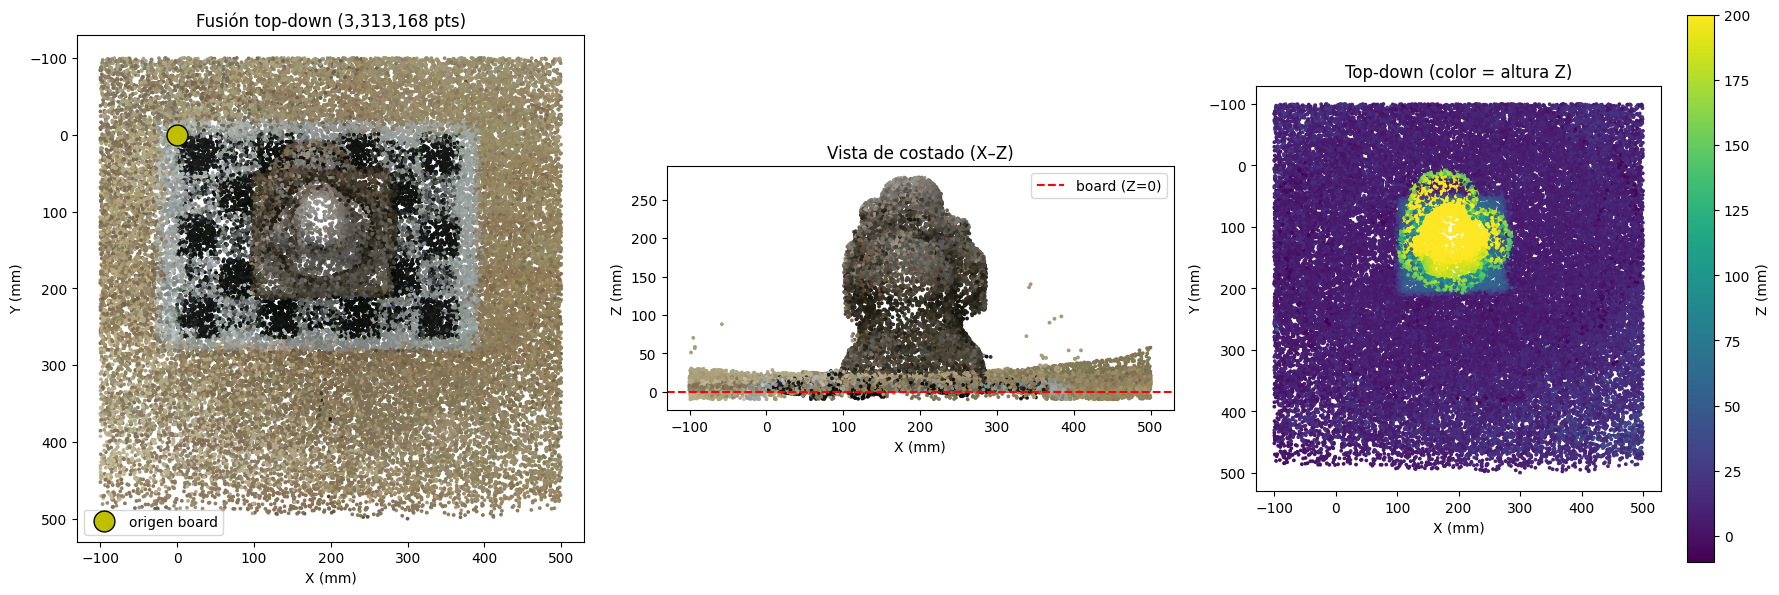

In [7]:
# Visualizacion de la nube final (3 vistas)
pts_f = np.asarray(acc_final.points)
col_f = np.asarray(acc_final.colors)

rng = np.random.default_rng(0)
if len(pts_f) > 50_000:
    sel = rng.choice(len(pts_f), 50_000, replace=False)
    pts_plot, col_plot = pts_f[sel], col_f[sel]
else:
    pts_plot, col_plot = pts_f, col_f

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].scatter(pts_plot[:, 0], pts_plot[:, 1], c=col_plot, s=3)
axes[0].set_aspect('equal'); axes[0].invert_yaxis()
axes[0].set_xlabel('X (mm)'); axes[0].set_ylabel('Y (mm)')
axes[0].set_title(f'Fusión top-down ({len(pts_f):,} pts)')
axes[0].plot(0, 0, 'yo', markersize=15, markeredgecolor='black', label='origen board')
axes[0].legend()

axes[1].scatter(pts_plot[:, 0], pts_plot[:, 2], c=col_plot, s=3)
axes[1].set_aspect('equal')
axes[1].set_xlabel('X (mm)'); axes[1].set_ylabel('Z (mm)')
axes[1].set_title('Vista de costado (X–Z)')
axes[1].axhline(0, color='red', ls='--', lw=1.5, label='board (Z=0)')
axes[1].legend()

sc = axes[2].scatter(pts_plot[:, 0], pts_plot[:, 1], c=pts_plot[:, 2], s=3, cmap='viridis', vmin=-10, vmax=200)
axes[2].set_aspect('equal'); axes[2].invert_yaxis()
axes[2].set_xlabel('X (mm)'); axes[2].set_ylabel('Y (mm)')
axes[2].set_title('Top-down (color = altura Z)')
plt.colorbar(sc, ax=axes[2], label='Z (mm)')

plt.tight_layout(); plt.show()

## 6. Exportar `.PLY` y estimar la altura del buda

Guardamos la nube final como PLY binario (más compacto que ASCII). La altura del buda se estima como la extensión sobre el eje vertical del mundo (`Z`, perpendicular al board). También reportamos las extensiones sobre `X` e `Y` como sanity-check de que la escala métrica sea razonable, y comparamos con una medición manual con regla.

In [8]:
out_ply = DATASET_DIR / 'buda_catedra.ply'
o3d.io.write_point_cloud(str(out_ply), acc_final, write_ascii=False)
print(f'PLY guardado: {out_ply}   ({len(acc_final.points):,} puntos)')

pts_f = np.asarray(acc_final.points)
extents = pts_f.max(axis=0) - pts_f.min(axis=0)
print(f'\nExtensiones de la nube (mm):')
print(f'  X: {extents[0]:.1f}')
print(f'  Y: {extents[1]:.1f}')
print(f'  Z: {extents[2]:.1f}   <-- altura del buda sobre el board')

# Altura del buda: usamos solo los puntos que probablemente son del buda (cerca
# del centro del board y por encima de Z=0) para evitar que ruido contamine.
buda_mask = (
    (pts_f[:, 2] > 5)            # > 5 mm sobre el board (evita la superficie)
    & (np.abs(pts_f[:, 0] - 130) < 80)   # cerca del X central del buda
    & (np.abs(pts_f[:, 1] - 130) < 80)   # cerca del Y central
)
if buda_mask.sum() > 100:
    altura_buda = float(pts_f[buda_mask, 2].max())
    print(f'\nAltura estimada del buda: {altura_buda:.1f} mm')
else:
    print('\nNo se pudieron aislar suficientes puntos del buda — ajustar mascara')

PLY guardado: datasets\stereo_budha_charuco\buda_catedra.ply   (3,313,168 puntos)

Extensiones de la nube (mm):
  X: 600.0
  Y: 600.0
  Z: 290.1   <-- altura del buda sobre el board

Altura estimada del buda: 280.1 mm


## 7. Reconstrucción de malla (Ball Pivoting)

Convertimos la nube de puntos en una **malla triangulada** — la salida canónica de reconstrucción 3D. El algoritmo de **Ball Pivoting** (Bernardini et al. 1999, usado por cátedra en [`3d.ipynb` cell 44](ejemplos%20clase/3d.ipynb)) "rueda" una bola virtual sobre la superficie del cloud y forma triángulos donde la bola toca tres puntos.

**Pre-requisitos**:
1. Aislar el buda con AABB (descartar el plano del board para que la mesh no incluya la mesa).
2. **Estimar normales** del cloud — el algoritmo necesita la dirección perpendicular a la superficie en cada punto.
3. **Orientar normales consistentemente** — sin esto, la mesh queda con triángulos volteados.
4. **Múltiples radios** de bola — capturan tanto detalle fino (radio chico) como zonas planas (radio grande).

Guardamos la mesh como `.ply` binario (mismo formato que la nube, pero incluye triángulos)."

In [9]:
# 7.1 Aislar el buda + estimar normales + Ball Pivoting

# AABB tight del buda: descarta el plano del board (Z > 3 mm) y el contorno lejano
buda_bbox_mesh = o3d.geometry.AxisAlignedBoundingBox(
    min_bound=np.array([-100.0, -100.0,   3.0]),
    max_bound=np.array([ 500.0,  500.0, 300.0]),
)
pcd_buda = acc_final.crop(buda_bbox_mesh)
pcd_buda, _ = pcd_buda.remove_statistical_outlier(nb_neighbors=30, std_ratio=2.0)
print(f'Buda aislado: {len(pcd_buda.points):,} puntos')

# Estimar normales (Ball Pivoting las necesita). KDTreeSearchParamHybrid usa
# radio (max distance) y max_nn (max neighbors) -- los puntos del buda estan
# espaciados ~1 mm despues del voxel downsample, asi que radio ~2 mm es razonable.
voxel_size = 1.0  # mm, mismo del downsample previo
pcd_buda.estimate_normals(
    search_param=o3d.geometry.KDTreeSearchParamHybrid(radius=voxel_size * 2, max_nn=30),
)
# Orientacion consistente para evitar normales flippeadas (triangulos al reves)
pcd_buda.orient_normals_consistent_tangent_plane(k=30)
print('Normales estimadas y orientadas')

# Ball Pivoting con varios radios (catedra usa np.linspace(1*voxel, 3*voxel, 5))
radii = o3d.utility.DoubleVector(np.linspace(voxel_size * 1.0, voxel_size * 3.0, 5))
print(f'Computando mesh con Ball Pivoting (radii: {list(radii)} mm)...')
mesh = o3d.geometry.TriangleMesh.create_from_point_cloud_ball_pivoting(pcd_buda, radii)
mesh.compute_vertex_normals()
print(f'Mesh: {len(mesh.vertices):,} vertices, {len(mesh.triangles):,} triangulos')

# Guardar como PLY binario
out_mesh = DATASET_DIR / 'buda_catedra_mesh.ply'
o3d.io.write_triangle_mesh(str(out_mesh), mesh, write_ascii=False)
print(f'\nMesh guardada: {out_mesh}')

Buda aislado: 2,887,120 puntos
Normales estimadas y orientadas
Computando mesh con Ball Pivoting (radii: [1.0, 1.5, 2.0, 2.5, 3.0] mm)...
Mesh: 2,887,120 vertices, 2,596,935 triangulos

Mesh guardada: datasets\stereo_budha_charuco\buda_catedra_mesh.ply


## 8. Vista interactiva final

Abrimos un viewer 3D para inspeccionar el resultado: mouse-drag rota, scroll zoom, shift-drag panea, `q` o `Esc` cierra.

Mostramos la **malla** (sección 7) en vez de la nube de puntos — se ve mucho más prolija con la superficie reconstruida. Si querés ver la nube original también, descomentá la línea correspondiente.

`o3d.visualization.draw_geometries` abre una ventana externa OpenGL nativa (funciona en Python local). Si no se abre (entornos remotos, Colab), fallback a `draw_plotly` que renderiza inline.

In [10]:
# 8.1 Viewer 3D interactivo

# Frame del mundo (X=rojo, Y=verde, Z=azul) como referencia visual en el origen
axes_frame = o3d.geometry.TriangleMesh.create_coordinate_frame(size=50.0, origin=[0, 0, 0])

# Lo que mostramos: la mesh por defecto. Descomentar `pcd_buda` para ver tambien la nube.
geometries = [mesh, axes_frame]
# geometries = [pcd_buda, mesh, axes_frame]

# Controles del viewer:
#   mouse-drag     -> rotar
#   scroll         -> zoom
#   shift + drag   -> panear
#   q o Esc        -> cerrar
try:
    o3d.visualization.draw_geometries(
        geometries,
        window_name='Buda 3D (mesh)  -  rotar: drag,  zoom: scroll,  pan: shift+drag',
        width=1280, height=800,
        mesh_show_back_face=True,   # ver ambos lados (triangulos con normal flippeada)
    )
except Exception as e:
    print(f'draw_geometries fallo ({e}). Fallback a plotly inline:')
    try:
        o3d.visualization.draw_plotly(geometries)
    except Exception as e2:
        print(f'draw_plotly tambien fallo: {e2}')
        print('Como ultimo recurso, abrir el .ply con MeshLab o CloudCompare.')